In [104]:
import os
import warnings
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from scipy.optimize import minimize
from scipy.stats import pearsonr

In [105]:
# Output directory
output = "ResearchProjectB"
os.makedirs(output, exist_ok=True)

In [106]:
# DLS function  (Project A)

def F_w(w, a1, a2, a3):
    return 1.0 + a1*w + a2*w**2 + a3*w**3

def Z0(G20, b):
    return G20 / (1.0 - np.exp(-20.0*b))

def Z_model(u, w, G20, b, a1, a2, a3):
    u  = np.asarray(u, float)
    w  = np.asarray(w, float)
    Fw = np.maximum(F_w(w, a1, a2, a3), 1e-8)
    return Z0(G20, b) * Fw * (1.0 - np.exp(-u*b/Fw))

def _bad(G20, b):
    return G20 <= 5 or G20 > 400 or b <= 1e-6 or b > 1.5

def L1_obj(p, u, w, r):
    if _bad(p[0], p[1]): return 1e12
    return float(np.sum(np.abs(r - Z_model(u, w, *p))))

def L2_obj(p, u, w, r):
    if _bad(p[0], p[1]): return 1e12
    return float(np.mean((r - Z_model(u, w, *p))**2))

def fit_model(u, w, r, label=""):
    #Two-stage L1-Powell to L2-LBFGSB fit.
    if len(r) < 80:
        print(f"  [SKIP] {label}  N={len(r)} < 80")
        return None, None
    u = np.clip(np.asarray(u, float), 0, 20)
    w = np.clip(np.asarray(w, float), 0, 9)
    r = np.asarray(r, float)
    x0     = [160., 0.07, -0.10, -0.005, 0.0005]
    bounds = [(50,400),(1e-4,.5),(-3.,3.),(-3.,3.),(-3.,3.)]
    r1 = minimize(L1_obj, x0, args=(u,w,r), method="Powell",
                  options=dict(maxiter=30000, maxfev=30000, xtol=1e-6, ftol=1e-6))
    r2 = minimize(L2_obj, r1.x, args=(u,w,r), method="L-BFGS-B", bounds=bounds,
                  options=dict(maxiter=20000))
    p    = r2.x
    pred = Z_model(u, w, *p)
    mae  = float(np.mean(np.abs(r - pred)))
    rmse = float(np.sqrt(np.mean((r-pred)**2)))
    print(f"  {label:<45}  G20={p[0]:6.1f}  b={p[1]:.4f}  "
          f"MAE={mae:.2f}  RMSE={rmse:.2f}  N={len(r):,}")
    return p, {"MAE": mae, "RMSE": rmse, "N": len(r)}

In [107]:
# Helper: wicket value table
def wicket_value_table(params, u_vals=None):
    # Compute the marginal wicket value at every combination of overs and wicket state
    if u_vals is None:
        u_vals = np.arange(1, 21, 1, dtype=float)
    rows = []
    for u in u_vals:
        row = {"overs_remaining": u}
        for wk in range(9):
            d = (Z_model(np.array([u]), np.array([float(wk)]),   *params) -
                 Z_model(np.array([u]), np.array([float(wk+1)]), *params))[0]
            row[f"w{wk} to w{wk+1}"] = round(d, 3)
        rows.append(row)
    return pd.DataFrame(rows)

def resource_pct_table(params, u_vals=None):
    # Produce a DLS-style resource percentage table
    if u_vals is None:
        u_vals = np.arange(0, 21, 1, dtype=float)
    z_max = Z_model(np.array([20.]), np.array([0.]), *params)[0]
    rows = []
    for u in u_vals:
        row = {"overs_remaining": u}
        for wk in range(10):
            z = Z_model(np.array([u]), np.array([float(wk)]), *params)[0]
            row[f"w{wk}"] = round(z / z_max * 100, 1)
        rows.append(row)
    return pd.DataFrame(rows)

def delta_w(u, wk, params):
    # Convenience wrapper: just compute delta_w for a single (u, wk) state
    return float(Z_model([u], [float(wk)],   *params) -
                 Z_model([u], [float(wk+1)], *params))
 

In [108]:
# helpers
u_grid = np.linspace(0, 20, 300)
wk_colors     = cm.tab10(np.linspace(0, 1, 10))

Phase_colors  = {"Powerplay": "#1f77b4", "Middle": "#ff7f0e", "Death": "#d62728"}
Phase_order   = ["Powerplay", "Middle", "Death"]
Phase_ranges  = {"Powerplay": (14., 20.), "Middle": (5., 14.), "Death": (0., 5.)}
Phase_eval  = {"Powerplay": 16., "Middle": 10., "Death": 2.}

team_names = {
    "Adelaide Strikers":   "Strikers",
    "Brisbane Heat":       "Heat",
    "Hobart Hurricanes":   "Hurricanes",
    "Melbourne Renegades": "Renegades",
    "Melbourne Stars":     "Stars",
    "Perth Scorchers":     "Scorchers",
    "Sydney Sixers":       "Sixers",
    "Sydney Thunder":      "Thunder",
}
team_colors = {
    "Adelaide Strikers":   "#005BBB",
    "Brisbane Heat":       "#E2231A",
    "Hobart Hurricanes":   "#6A1785",
    "Melbourne Renegades": "#E2131A",
    "Melbourne Stars":     "#1B7A3E",
    "Perth Scorchers":     "#F47920",
    "Sydney Sixers":       "#FF69B4",
    "Sydney Thunder":      "#FFD700",
}
def _tcolor(team, fallback_cmap, idx):
    return team_colors.get(team, fallback_cmap(idx))
 
def _tname(team):
    return team_names.get(team, team.split()[-1])
 

In [109]:
# Data loading

def load_data(path="ResearchProjectA/cleaned_ball_by_ball_data.csv"):
    # Load and validate the Project A cleaned CSV
    if not os.path.exists(path):
        raise FileNotFoundError(f"Cannot find '{path}'. Run Project A notebook first.")
    df = pd.read_csv(path)
    required = {"overs_remaining", "wickets_lost", "runs_to_come", "venue", "over"}
    df["overs_remaining"] = df["balls_remaining"] / 6.0
    miss = required - set(df.columns)
    if miss:
        raise ValueError(f"Missing columns: {miss}")
    df["overs_remaining"] = np.clip(df["overs_remaining"], 0, 20)
    df["wickets_lost"]    = np.clip(df["wickets_lost"],    0, 9)
    df = df.dropna(subset=["overs_remaining", "wickets_lost", "runs_to_come"])
    # Phase assignment
    df["phase"] = df["over"].apply(
        lambda o: "Powerplay" if o <= 6 else ("Middle" if o <= 15 else "Death")
    )
    print(f"Loaded {len(df):,} first-innings rows.")
    return df

In [110]:
# Global baseline

def fit_global(df):
    print("GLOBAL BASELINE (Project A replication)")
    params, metrics = fit_model(
        df["overs_remaining"].values,
        df["wickets_lost"].values,
        df["runs_to_come"].values,
        label="Global baseline"
    )
    return params, metrics

In [111]:
# Module 1: Venue specific

def module_venue(df, global_params, min_matches=20):
    subdir = f"{OUT}/venue"
    os.makedirs(subdir, exist_ok=True)
    print("Module 1: Venue specific")

    # Count matches per venue
    vcounts = (df.groupby("venue")["match_id"].nunique()
                 .rename("n_matches").reset_index())
    eligible = vcounts[vcounts["n_matches"] >= min_matches]["venue"].tolist()
    print(f"Eligible venues (≥{min_matches} matches): {len(eligible)}")

    venue_params = {}
    rows = []
    for venue in eligible:
        sub = df[df["venue"] == venue]
        p, m = fit_model(sub["overs_remaining"].values,
                         sub["wickets_lost"].values,
                         sub["runs_to_come"].values, label=venue)
        if p is None: continue
        venue_params[venue] = p
        n = int(vcounts.set_index("venue").loc[venue, "n_matches"])
        rows.append({"venue": venue, "n_matches": n,
                     "G20": p[0], "b": p[1],
                     "a1": p[2], "a2": p[3], "a3": p[4], **m})

    params_df = pd.DataFrame(rows).sort_values("G20", ascending=False)
    params_df.to_csv(f"{subdir}/venue_params.csv", index=False)

    # Save wicket-value and resource tables per venue
    for venue, p in venue_params.items():
        safe = venue.replace(" ", "_").replace(",","").replace("/","-")[:45]
        wicket_value_table(p).to_csv(
            f"{subdir}/wv_table_{safe}.csv", index=False)
        resource_pct_table(p).to_csv(
            f"{subdir}/resource_pct_{safe}.csv", index=False)

    # V1: G20 and b bar chart
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    y = range(len(params_df))
    venues_sorted = params_df["venue"].tolist()

    axes[0].barh(venues_sorted, params_df["G20"], color="#4C72B0", alpha=0.85)
    axes[0].axvline(global_params[0], color="crimson", linestyle="--",
                    linewidth=2, label=f"Global G20 = {global_params[0]:.1f}")
    axes[0].set_xlabel("G20 (Implied 20-over total)", fontsize=11)
    axes[0].set_title("Venue-Specific Scoring Potential (G20)", fontsize=12)
    axes[0].legend(fontsize=10); axes[0].grid(axis="x", linestyle="--", alpha=0.4)
    for i, (v, val) in enumerate(zip(venues_sorted, params_df["G20"])):
        axes[0].text(val + 0.3, i, f"{val:.1f}", va="center", fontsize=9)

    axes[1].barh(venues_sorted, params_df["b"], color="#DD8452", alpha=0.85)
    axes[1].axvline(global_params[1], color="crimson", linestyle="--",
                    linewidth=2, label=f"Global b = {global_params[1]:.4f}")
    axes[1].set_xlabel("b (Resource decay rate)", fontsize=11)
    axes[1].set_title("Venue-Specific Resource Decay Rate (b)", fontsize=12)
    axes[1].legend(fontsize=10); axes[1].grid(axis="x", linestyle="--", alpha=0.4)
    for i, (v, val) in enumerate(zip(venues_sorted, params_df["b"])):
        axes[1].text(val + 0.0003, i, f"{val:.4f}", va="center", fontsize=9)

    plt.suptitle("Venue-Specific DLS Parameters vs Global Baseline",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{subdir}/V1_venue_G20_b.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # V2: Overlay resource curves

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    cmap_v = cm.get_cmap("tab10", len(venue_params))
    v_colors = {v: cmap_v(i) for i, v in enumerate(venue_params)}

    for ax_idx, wk in enumerate([0, 3, 6, 9]):
        ax = axes[ax_idx]
        # Global baseline
        z_g = Z_model(u_grid, np.full_like(u_grid, wk), *global_params)
        ax.plot(u_grid, z_g, "k--", linewidth=2.5, label="Global baseline", zorder=10)
        for venue, p in venue_params.items():
            z = Z_model(u_grid, np.full_like(u_grid, wk), *p)
            short = venue.split(",")[0].replace(" Cricket Ground","").strip()
            ax.plot(u_grid, z, color=v_colors[venue], linewidth=1.5,
                    alpha=0.85, label=short)
        ax.set_title(f"w = {wk} wickets lost", fontsize=11)
        ax.set_xlabel("Overs Remaining"); ax.set_ylabel("Expected Runs to Come")
        ax.grid(linestyle="--", alpha=0.4)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center right",
               bbox_to_anchor=(1.15, 0.5), fontsize=8, frameon=True)
    plt.suptitle("Venue-Specific Resource Curves vs Global Baseline\n"
                 "(at w=0, 3, 6, 9 wickets lost)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{subdir}/V2_venue_resource_overlay.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # V3: Wicket value heatmap
    wv_mat = np.zeros((len(venue_params), 9))
    venue_list = list(venue_params.keys())
    for i, venue in enumerate(venue_list):
        for wk in range(9):
            wv_mat[i, wk] = (
                Z_model([10.], [float(wk)],   *venue_params[venue]) -
                Z_model([10.], [float(wk+1)], *venue_params[venue])
            )[0]

    short_venues = [v.split(",")[0].replace(" Cricket Ground","").strip()
                    for v in venue_list]
    fig, ax = plt.subplots(figsize=(14, max(5, len(venue_list)*0.6 + 1)))
    im = ax.imshow(wv_mat, aspect="auto", cmap="YlOrRd",
                   vmin=0, vmax=max(8, wv_mat.max()))
    plt.colorbar(im, ax=ax, label="Expected runs lost  Δ_w(u=10)")
    ax.set_xticks(range(9))
    ax.set_xticklabels([f"w{w} to w{w+1}" for w in range(9)], fontsize=10)
    ax.set_yticks(range(len(venue_list)))
    ax.set_yticklabels(short_venues, fontsize=10)
    for i in range(len(venue_list)):
        for j in range(9):
            tc = "white" if wv_mat[i, j] > wv_mat.max()*0.7 else "black"
            ax.text(j, i, f"{wv_mat[i,j]:.1f}", ha="center", va="center",
                    fontsize=8, color=tc)
    ax.set_title("Wicket Value Heatmap by Venue\n"
                 "(Expected runs lost per dismissal at u=10 overs remaining)",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Wicket Transition"); ax.set_ylabel("Venue")
    plt.tight_layout()
    plt.savefig(f"{subdir}/V3_venue_wicket_value_heatmap.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


    print(f"\n Module 1 saved to {subdir}/")
    return venue_params, params_df

In [112]:
# Module 2: phase specific

def module_phase(df, global_params):
    subdir = f"{OUT}/phase"
    os.makedirs(subdir, exist_ok=True)
    print("Module 2: Phase specific")

    phase_params = {}
    rows = []
    for phase in Phase_order:
        sub = df[df["phase"] == phase]
        p, m = fit_model(sub["overs_remaining"].values,
                         sub["wickets_lost"].values,
                         sub["runs_to_come"].values, label=phase)
        if p is None: continue
        phase_params[phase] = p
        rows.append({"phase": phase, "G20": p[0], "b": p[1],
                     "a1": p[2], "a2": p[3], "a3": p[4], **m})

    params_df = pd.DataFrame(rows)
    params_df.to_csv(f"{subdir}/phase_params.csv", index=False)

    for phase, p in phase_params.items():
        wicket_value_table(p).to_csv(
            f"{subdir}/wv_table_{phase}.csv", index=False)
        resource_pct_table(p).to_csv(
            f"{subdir}/resource_pct_{phase}.csv", index=False)

    # P1: Full resource surfaces
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, phase in zip(axes, Phase_order):
        if phase not in phase_params: continue
        p = phase_params[phase]
        lo, hi = Phase_ranges[phase]
        u_seg  = np.linspace(lo, hi, 200)
        for wk in range(10):
            z = Z_model(u_seg, np.full_like(u_seg, wk), *p)
            ax.plot(u_seg, z, color=wk_colors[wk], linewidth=1.6,
                    label=f"w={wk}")
        ax.set_title(f"{phase}\nG20={p[0]:.1f},  b={p[1]:.4f}",
                     fontsize=11, color=Phase_colors[phase])
        ax.set_xlabel("Overs Remaining"); ax.set_ylabel("Expected Runs to Come")
        ax.legend(fontsize=6.5, ncol=2, loc="upper left")
        ax.grid(linestyle="--", alpha=0.4)
        ax.spines["top"].set_color(Phase_colors[phase])
        ax.spines["bottom"].set_color(Phase_colors[phase])
    plt.suptitle("Phase-Specific DLS Resource Surfaces\n"
                 "(fitted only on data within each phase's natural over range)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{subdir}/P1_phase_full_surfaces.png", dpi=150)
    plt.show()
    plt.close()

    # P2: Continuous innings overlay
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, wk, title in zip(axes, [0, 5],
                              ["0 Wickets Lost", "5 Wickets Lost"]):
        for phase in Phase_order:
            if phase not in phase_params: continue
            lo, hi = Phase_ranges[phase]
            u_seg  = np.linspace(lo, hi, 150)
            z_seg  = Z_model(u_seg, np.full_like(u_seg, wk),
                             *phase_params[phase])
            ax.plot(u_seg, z_seg, color=Phase_colors[phase],
                    linewidth=2.5, label=phase)
        # Global baseline
        z_g = Z_model(u_grid, np.full_like(u_grid, wk), *global_params)
        ax.plot(u_grid, z_g, "k--", linewidth=1.8, alpha=0.6,
                label="Global baseline")
        ax.set_xlabel("Overs Remaining"); ax.set_ylabel("Expected Runs to Come")
        ax.set_title(f"Phase Resource Curves — {title}", fontsize=11)
        ax.legend(fontsize=9); ax.grid(linestyle="--", alpha=0.4)
    plt.suptitle("Phase Resource Curves vs Global Baseline",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{subdir}/P2_phase_overlay.png", dpi=150)
    plt.show()
    plt.close()

    # P3: Wicketvalue heatmap
    
    wv_mat = np.zeros((3, 9))
    for i, phase in enumerate(Phase_order):
        if phase not in phase_params: continue
        u_e = Phase_eval[phase]
        for wk in range(9):
            wv_mat[i, wk] = (
                Z_model([u_e], [float(wk)],   *phase_params[phase]) -
                Z_model([u_e], [float(wk+1)], *phase_params[phase])
            )[0]

    pd.DataFrame(wv_mat, index=Phase_order,
                 columns=[f"w{w} to w{w+1}" for w in range(9)]
                 ).to_csv(f"{subdir}/phase_wicket_value.csv")

    fig, ax = plt.subplots(figsize=(13, 3.5))
    im = ax.imshow(wv_mat, aspect="auto", cmap="YlOrRd",
                   vmin=0, vmax=max(5, wv_mat.max()))
    plt.colorbar(im, ax=ax, label="Expected runs lost  Δ_w(u)")
    ax.set_xticks(range(9))
    ax.set_xticklabels([f"w{w} to w{w+1}" for w in range(9)], fontsize=10)
    ax.set_yticks(range(3)); ax.set_yticklabels(Phase_order, fontsize=11)
    for i in range(3):
        for j in range(9):
            tc = "white" if wv_mat[i,j] > wv_mat.max()*0.75 else "black"
            ax.text(j, i, f"{wv_mat[i,j]:.1f}", ha="center", va="center",
                    fontsize=9, color=tc, fontweight="bold")
    ax.set_title("Phase Wicket Value Heatmap\n"
                 "(PP=16 overs, Mid=10 overs, Death=2 overs remaining)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{subdir}/P3_phase_wicket_value_heatmap.png", dpi=150)
    plt.show()
    plt.close()

    # P4: Wicket value line chart
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    linestyles = ["-","--","-.",":","(0,(3,1,1,1))"]
    for ax, phase in zip(axes, Phase_order):
        if phase not in phase_params: continue
        lo, hi = Phase_ranges[phase]
        u_seg  = np.linspace(lo, hi, 200)
        for wk in range(5):
            delta = (Z_model(u_seg, np.full_like(u_seg, float(wk)),   *phase_params[phase]) -
                     Z_model(u_seg, np.full_like(u_seg, float(wk+1)), *phase_params[phase]))
            ls = ["-","--","-.",":",(0,(5,1))][wk]
            ax.plot(u_seg, delta, color=wk_colors[wk], linewidth=2,
                    linestyle=ls, label=f"w{wk} to w{wk+1}")
        ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
        ax.set_xlabel("Overs Remaining")
        ax.set_ylabel("Expected runs lost  Δ_w(u)")
        ax.set_title(f"Wicket Value Through {phase}", fontsize=11,
                     color=Phase_colors[phase])
        ax.legend(fontsize=8); ax.grid(linestyle="--", alpha=0.4)
    plt.suptitle("How Wicket Value Changes Across Overs — By Phase",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{subdir}/P4_phase_wicket_value_over_overs.png", dpi=150)
    plt.show()
    plt.close()

    print(f"\n Module 2 saved to {subdir}/")
    return phase_params, params_df


In [113]:
# module 3: Team specific

def module_team(df, global_params):
    subdir = f"{OUT}/team"
    os.makedirs(subdir, exist_ok=True)
    print("Module 3: Team specific")

    # Identify the batting team column
    team_col = next(
        (c for c in ["batting_team", "team", "bat_team"] if c in df.columns),
        None
    )
    if team_col is None:
        raise ValueError("No team column found. Expected: 'batting_team', 'team', 'bat_team'.")
 
    teams = sorted(df[team_col].dropna().unique().tolist())
    print(f"Teams found: {teams}")
    

    team_params = {}
    rows = []
    for team in teams:
        sub = df[df[team_col] == team]
        p, m = fit_model(sub["overs_remaining"].values,
                         sub["wickets_lost"].values,
                         sub["runs_to_come"].values, label=team)
        if p is None: continue
        team_params[team] = p
        n_matches = sub["match_id"].nunique() if "match_id" in sub.columns else len(sub)
        rows.append({"team": team, "n_deliveries": len(sub),
                     "G20": p[0], "b": p[1],
                     "a1": p[2], "a2": p[3], "a3": p[4], **m})

    params_df = pd.DataFrame(rows).sort_values("G20", ascending=False)
    params_df.to_csv(f"{subdir}/team_params.csv", index=False)

    for team, p in team_params.items():
        safe = team.replace(" ","_")
        wicket_value_table(p).to_csv(
            f"{subdir}/wv_table_{safe}.csv", index=False)
        resource_pct_table(p).to_csv(
            f"{subdir}/resource_pct_{safe}.csv", index=False)

    # Build consistent color map
    cmap_t   = cm.get_cmap("tab10", len(team_params))
    all_sorted_teams = sorted(team_params)
    t_colors = {t: _tcolor(t, cmap_t, i)
                for i, t in enumerate(all_sorted_teams)}

    # T1: G20 and b bar chart

    teams_sorted = params_df["team"].tolist()
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].barh(teams_sorted, params_df["G20"],
                 color=[t_colors[t] for t in teams_sorted], alpha=0.85)
    axes[0].axvline(global_params[0], color="black", linestyle="--",
                    linewidth=2, label=f"Global G20={global_params[0]:.1f}")
    axes[0].set_xlabel("G20 (Implied 20-over total)", fontsize=11)
    axes[0].set_title("Team-Specific Scoring Potential (G20)\n"
                      "sorted highest to lowest", fontsize=11)
    axes[0].legend(fontsize=9); axes[0].grid(axis="x", linestyle="--", alpha=0.4)
    for i, (t, val) in enumerate(zip(teams_sorted, params_df["G20"])):
        axes[0].text(val+0.3, i, f"{val:.1f}", va="center", fontsize=9)

    axes[1].barh(teams_sorted, params_df["b"],
                 color=[t_colors[t] for t in teams_sorted], alpha=0.85)
    axes[1].axvline(global_params[1], color="black", linestyle="--",
                    linewidth=2, label=f"Global b={global_params[1]:.4f}")
    axes[1].set_xlabel("b (Resource decay rate)", fontsize=11)
    axes[1].set_title("Team-Specific Decay Rate (b)\n"
                      "higher = faster resource burn", fontsize=11)
    axes[1].legend(fontsize=9); axes[1].grid(axis="x", linestyle="--", alpha=0.4)
    for i, (t, val) in enumerate(zip(teams_sorted, params_df["b"])):
        axes[1].text(val+0.0003, i, f"{val:.4f}", va="center", fontsize=9)

    plt.suptitle("Team-Specific DLS Parameters vs Global Baseline",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{subdir}/T1_team_G20_b.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # T2: Full resource curves
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, wk, title in zip(axes, [0, 5],
                              ["0 Wickets Lost", "5 Wickets Lost"]):
        z_g = Z_model(u_grid, np.full_like(u_grid, wk), *global_params)
        ax.plot(u_grid, z_g, "k--", linewidth=2.5,
                label="Global baseline", zorder=10)
        for team, p in team_params.items():
            z = Z_model(u_grid, np.full_like(u_grid, wk), *p)
            ax.plot(u_grid, z, color=t_colors[team], linewidth=1.8,
                    alpha=0.85, label=team)
        ax.set_xlabel("Overs Remaining"); ax.set_ylabel("Expected Runs to Come")
        ax.set_title(f"Team Resource Curves — {title}", fontsize=11)
        ax.grid(linestyle="--", alpha=0.4)
    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center right",
               bbox_to_anchor=(1.13, 0.5), fontsize=8.5, frameon=True)
    plt.suptitle("Team-Specific Resource Curves vs Global Baseline",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{subdir}/T2_team_resource_overlay.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # T3: Wicket value heatmap
    
    team_list = list(team_params.keys())
    wv_mat = np.zeros((len(team_list), 9))
    for i, team in enumerate(team_list):
        for wk in range(9):
            wv_mat[i, wk] = (
                Z_model([10.], [float(wk)],   *team_params[team]) -
                Z_model([10.], [float(wk+1)], *team_params[team])
            )[0]

    fig, ax = plt.subplots(figsize=(14, max(5, len(team_list)*0.7+1)))
    im = ax.imshow(wv_mat, aspect="auto", cmap="YlOrRd",
                   vmin=0, vmax=max(8, wv_mat.max()))
    plt.colorbar(im, ax=ax, label="Expected runs lost  Δ_w(u=10)")
    ax.set_xticks(range(9))
    ax.set_xticklabels([f"w{w} to w{w+1}" for w in range(9)], fontsize=10)
    ax.set_yticks(range(len(team_list)))
    ax.set_yticklabels(team_list, fontsize=10)
    for i in range(len(team_list)):
        for j in range(9):
            tc = "white" if wv_mat[i,j] > wv_mat.max()*0.72 else "black"
            ax.text(j, i, f"{wv_mat[i,j]:.1f}", ha="center", va="center",
                    fontsize=8.5, color=tc)
    ax.set_title("Team Wicket Value Heatmap\n"
                 "(Expected runs lost per dismissal at u=10 overs remaining)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{subdir}/T3_team_wicket_value_heatmap.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


    # T4: Phase - Team interaction
    print("\nFitting phase×team interaction models...")
    phase_team_G20 = {}
    for phase in Phase_order:
        phase_team_G20[phase] = {}
        sub_phase = df[df["phase"] == phase]
        for team in sorted(team_params.keys()):
            sub = sub_phase[sub_phase[team_col] == team]
            p, _ = fit_model(sub["overs_remaining"].values,
                             sub["wickets_lost"].values,
                             sub["runs_to_come"].values,
                             label=f"{phase}×{team}")
            if p is not None:
                phase_team_G20[phase][team] = p[0]

    all_teams_pt = sorted(set(
        t for pd_ in phase_team_G20.values() for t in pd_.keys()
    ))
    x = np.arange(len(all_teams_pt))
    width = 0.28
    fig, ax = plt.subplots(figsize=(14, 6))
    for i, phase in enumerate(Phase_order):
        g20_vals = [phase_team_G20[phase].get(t, np.nan) for t in all_teams_pt]
        offset   = (i - 1) * width
        ax.bar(x + offset, g20_vals, width, label=phase,
               color=Phase_colors[phase], alpha=0.82, edgecolor="white")
    ax.axhline(global_params[0], color="black", linestyle="--",
               linewidth=1.8, label=f"Global G20={global_params[0]:.1f}")
    ax.set_xticks(x); ax.set_xticklabels(all_teams_pt, rotation=35,
                                          ha="right", fontsize=9)
    ax.set_ylabel("G20 (Implied 20-over total)", fontsize=11)
    ax.set_title("G20 by Team and Phase — Interaction Plot\n"
                 "(shows how each team's scoring potential varies across phases)",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=9); ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(f"{subdir}/T4_team_phase_G20_interaction.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # T5:Team wicket value line chart
    
    fig, ax = plt.subplots(figsize=(12, 6))
    z_g = (Z_model(u_grid, np.full_like(u_grid, 3.), *global_params) -
           Z_model(u_grid, np.full_like(u_grid, 4.), *global_params))
    ax.plot(u_grid, z_g, "k--", linewidth=2.5,
            label="Global baseline", zorder=10)
    for team, p in team_params.items():
        delta = (Z_model(u_grid, np.full_like(u_grid, 3.), *p) -
                 Z_model(u_grid, np.full_like(u_grid, 4.), *p))
        ax.plot(u_grid, delta, color=t_colors[team], linewidth=1.8,
                alpha=0.85, label=team)
    ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
    ax.set_xlabel("Overs Remaining", fontsize=11)
    ax.set_ylabel("Runs lost  Δ  (w3 to w4)", fontsize=11)
    ax.set_title("Value of the 4th Wicket Across the Innings — By Team\n"
                 "(w3 to w4 transition)", fontsize=12, fontweight="bold")
    ax.legend(fontsize=8, ncol=2, loc="upper left")
    ax.grid(linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(f"{subdir}/T5_team_4th_wicket_value.png", dpi=150)
    plt.show()
    plt.close()

    # T6: Batting style quadrant

    g20s_q = np.array([team_params[t][0] for t in team_params])
    bs_q   = np.array([team_params[t][1] for t in team_params])
    fig, ax = plt.subplots(figsize=(11, 8))
    for team, p in team_params.items():
        col = t_colors[team]
        ax.scatter(p[0], p[1], s=800, color=col, alpha=0.82,
                   edgecolors="white", linewidths=2, zorder=5)
        ax.text(p[0], p[1] + (global_params[1]*0.018),
                _tshort(team), ha="center", fontsize=10,
                fontweight="bold", color=col, zorder=6)
    ax.axvline(global_params[0], color="black", linestyle="--", linewidth=1.5, alpha=0.6)
    ax.axhline(global_params[1], color="black", linestyle="--", linewidth=1.5, alpha=0.6)
    x_pad = (g20s_q.max()-g20s_q.min())*0.04
    y_pad = (bs_q.max()-bs_q.min())*0.04
    quad_labels = [
        (g20s_q.min()+x_pad, bs_q.max()-y_pad, "FAST STARTERS\n(Moderate total,\naggressive early)", "left","top"),
        (g20s_q.max()-x_pad, bs_q.max()-y_pad, "POWER HITTERS\n(Big total,\naggressive early)",    "right","top"),
        (g20s_q.min()+x_pad, bs_q.min()+y_pad, "STEADY BATTERS\n(Moderate total,\npatient build)", "left","bottom"),
        (g20s_q.max()-x_pad, bs_q.min()+y_pad, "BUILDERS\n(Big total,\npatient build)",            "right","bottom"),
    ]
    for xq, yq, txt, ha, va in quad_labels:
        ax.text(xq, yq, txt, ha=ha, va=va, fontsize=9, color="dimgray",
                style="italic",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="lightgray", alpha=0.7))
    ax.set_xlabel("G20 — Expected Total Runs to Higher = bigger scoring ceiling", fontsize=11)
    ax.set_ylabel("b — Resource Decay Rate to  Higher = team peaks earlier", fontsize=11)
    ax.set_title("\"What's This Team's Batting Style?\" — Scoring Ceiling vs Pace\n"
                 "Dashed lines = BBL average. Quadrants show batting archetype.",
                 fontsize=12, fontweight="bold")
    ax.grid(linestyle="--", alpha=0.3)
    ax.text(0.5, -0.13,
            "Top-right = big total AND fast start. Bottom-right = patient build to a big total.\n"
            "Top-left = attack early but moderate ceiling. Bottom-left = most conservative.",
            transform=ax.transAxes, ha="center", fontsize=9,
            style="italic", color="dimgray")
    plt.tight_layout()
    plt.savefig(f"{subdir}/T6_batting_style_quadrant.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

 
    print(f"\n Module 3 saved to {subdir}/")
    return team_params, params_df, team_col

In [114]:
# cross comparison

def cross_comparison(global_params, venue_params, phase_params, team_params):
    subdir = f"{OUT}/cross_comparison"
    os.makedirs(subdir, exist_ok=True)
    print("Cross comparison")

    u_val = np.array([10.0])
    wk    = 3

    rows = []
    for label, params in (venue_params or {}).items():
        d = (Z_model(u_val, [float(wk)],   *params) -
             Z_model(u_val, [float(wk+1)], *params))[0]
        rows.append({"dimension": "Venue", "group": label,
                     "G20": params[0], "b": params[1],
                     "delta_w3_u10": d})

    for label, params in (phase_params or {}).items():
        d = (Z_model(u_val, [float(wk)],   *params) -
             Z_model(u_val, [float(wk+1)], *params))[0]
        rows.append({"dimension": "Phase", "group": label,
                     "G20": params[0], "b": params[1],
                     "delta_w3_u10": d})

    for label, params in (team_params or {}).items():
        d = (Z_model(u_val, [float(wk)],   *params) -
             Z_model(u_val, [float(wk+1)], *params))[0]
        rows.append({"dimension": "Team", "group": label,
                     "G20": params[0], "b": params[1],
                     "delta_w3_u10": d})

    # Add global
    d_g = (Z_model(u_val, [float(wk)],   *global_params) -
           Z_model(u_val, [float(wk+1)], *global_params))[0]
    rows.append({"dimension": "Global", "group": "All BBL",
                 "G20": global_params[0], "b": global_params[1],
                 "delta_w3_u10": d_g})

    summary_df = pd.DataFrame(rows)
    summary_df.to_csv(f"{subdir}/cross_comparison_summary.csv", index=False)
    print(summary_df.to_string(index=False))

    dim_colors = {"Venue": "#4C72B0", "Phase": "#DD8452",
                  "Team": "#55A868", "Global": "black"}

    
    # C1: G20 across all strata
    fig, axes = plt.subplots(1, 2, figsize=(18, 9))
    for dim in summary_df["dimension"].unique():
        sub = summary_df[summary_df["dimension"] == dim]
        axes[0].barh(sub["group"], sub["G20"],
                     color=dim_colors.get(dim, "gray"), alpha=0.75, label=dim)
        axes[1].barh(sub["group"], sub["delta_w3_u10"],
                     color=dim_colors.get(dim, "gray"), alpha=0.75, label=dim)
    # Global reference lines
    axes[0].axvline(global_params[0], color="black", linestyle="--",
                    linewidth=1.8, label=f"Global G20={global_params[0]:.1f}")
    axes[1].axvline(d_g, color="black", linestyle="--",
                    linewidth=1.8, label=f"Global δ={d_g:.2f}")
    for ax, xlabel, title in zip(
            axes,
            ["G20 (Implied 20-over total)",
             "Expected runs lost  w3 to w4  at u=10"],
            ["G20 Across All Strata",
             "4th Wicket Value at 10 Overs — All Strata"]
    ):
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.legend(fontsize=9, loc="lower right")
        ax.grid(axis="x", linestyle="--", alpha=0.4)
    plt.suptitle("Cross-Comparison: Venue / Phase / Team\n"
                 "DLS Resource Parameters and Wicket Values",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{subdir}/C1_cross_comparison_G20_delta.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


    # C2: Wicket value range (min/max/mean) per dimension
    dims_to_plot = ["Venue", "Phase", "Team"]
    fig, ax = plt.subplots(figsize=(9, 5))
    x_pos = np.arange(len(dims_to_plot))
    for i, dim in enumerate(dims_to_plot):
        sub = summary_df[summary_df["dimension"] == dim]["delta_w3_u10"]
        if sub.empty: continue
        mn, mx, me = sub.min(), sub.max(), sub.mean()
        ax.bar(i, mx - mn, bottom=mn, width=0.45,
               color=dim_colors[dim], alpha=0.7,
               label=f"{dim}  (range={mx-mn:.1f})")
        ax.scatter(i, me, color=dim_colors[dim], s=120, zorder=5,
                   edgecolors="black", linewidths=0.8)
        ax.text(i + 0.25, me, f"mean={me:.1f}", va="center", fontsize=9)
    ax.axhline(d_g, color="black", linestyle="--", linewidth=1.8,
               label=f"Global δ={d_g:.2f}")
    ax.set_xticks(x_pos); ax.set_xticklabels(dims_to_plot, fontsize=11)
    ax.set_ylabel("Runs lost  w3 to w4  at u=10", fontsize=11)
    ax.set_title("Range of 4th Wicket Values Across Each Dimension\n"
                 "(bar = min–max range, dot = mean)",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=9); ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(f"{subdir}/C2_cross_wicket_value_range.png", dpi=150)
    plt.show()
    plt.close()

    print(f"\n Cross-comparison saved to {subdir}/")
    return summary_df


Loaded 71,530 first-innings rows.
GLOBAL BASELINE (Project A replication)
  Global baseline                                G20= 156.4  b=0.0397  MAE=13.83  RMSE=18.96  N=71,530
Module 1: Venue specific
Eligible venues (≥20 matches): 10
  Adelaide Oval                                  G20= 160.0  b=0.0411  MAE=14.54  RMSE=19.01  N=9,142
  Bellerive Oval, Hobart                         G20= 163.7  b=0.0237  MAE=10.77  RMSE=14.46  N=7,651
  Brisbane Cricket Ground, Woolloongabba, Brisbane  G20= 156.4  b=0.0330  MAE=13.15  RMSE=17.33  N=7,129
  Docklands Stadium, Melbourne                   G20= 158.0  b=0.0471  MAE=13.08  RMSE=18.15  N=8,247
  Manuka Oval, Canberra                          G20= 157.3  b=0.0301  MAE=11.19  RMSE=14.98  N=3,098
  Melbourne Cricket Ground                       G20= 149.0  b=0.0556  MAE=13.89  RMSE=19.45  N=8,351
  Perth Stadium                                  G20= 156.8  b=0.0578  MAE=14.37  RMSE=19.97  N=4,861
  Sydney Cricket Ground, Sydney                

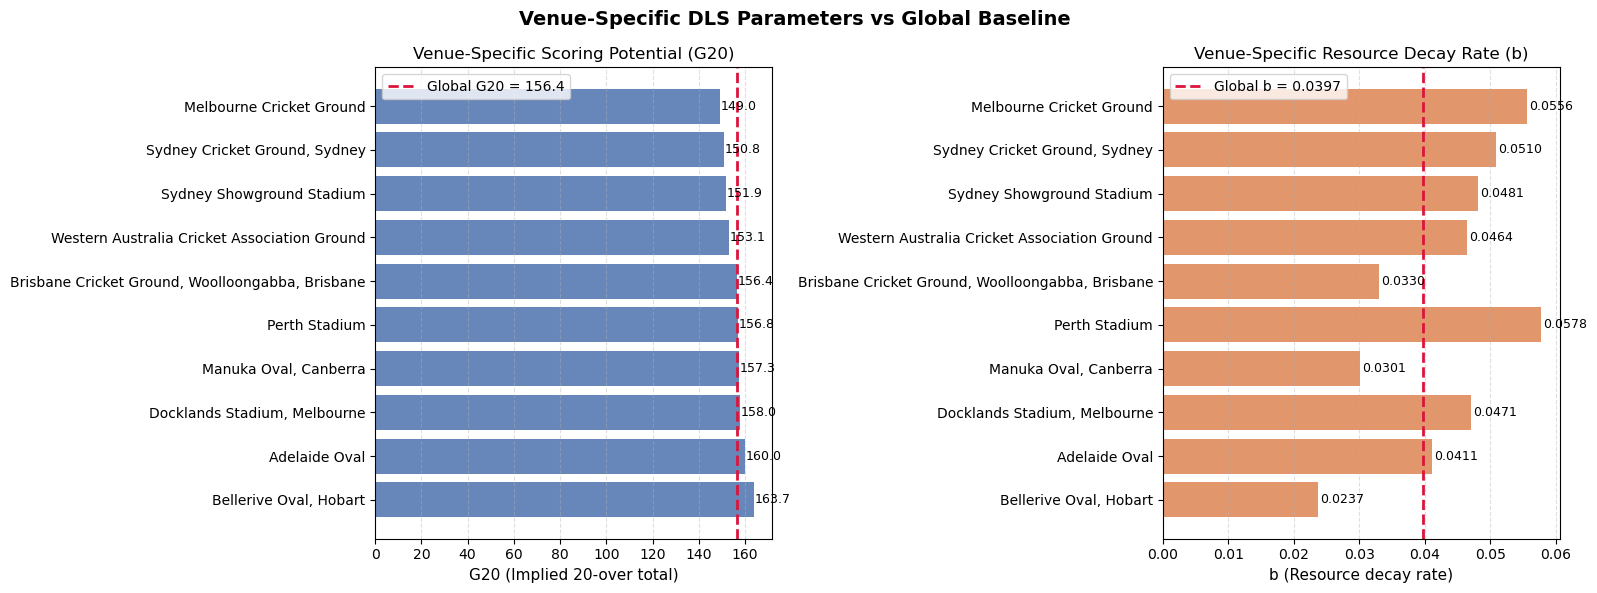

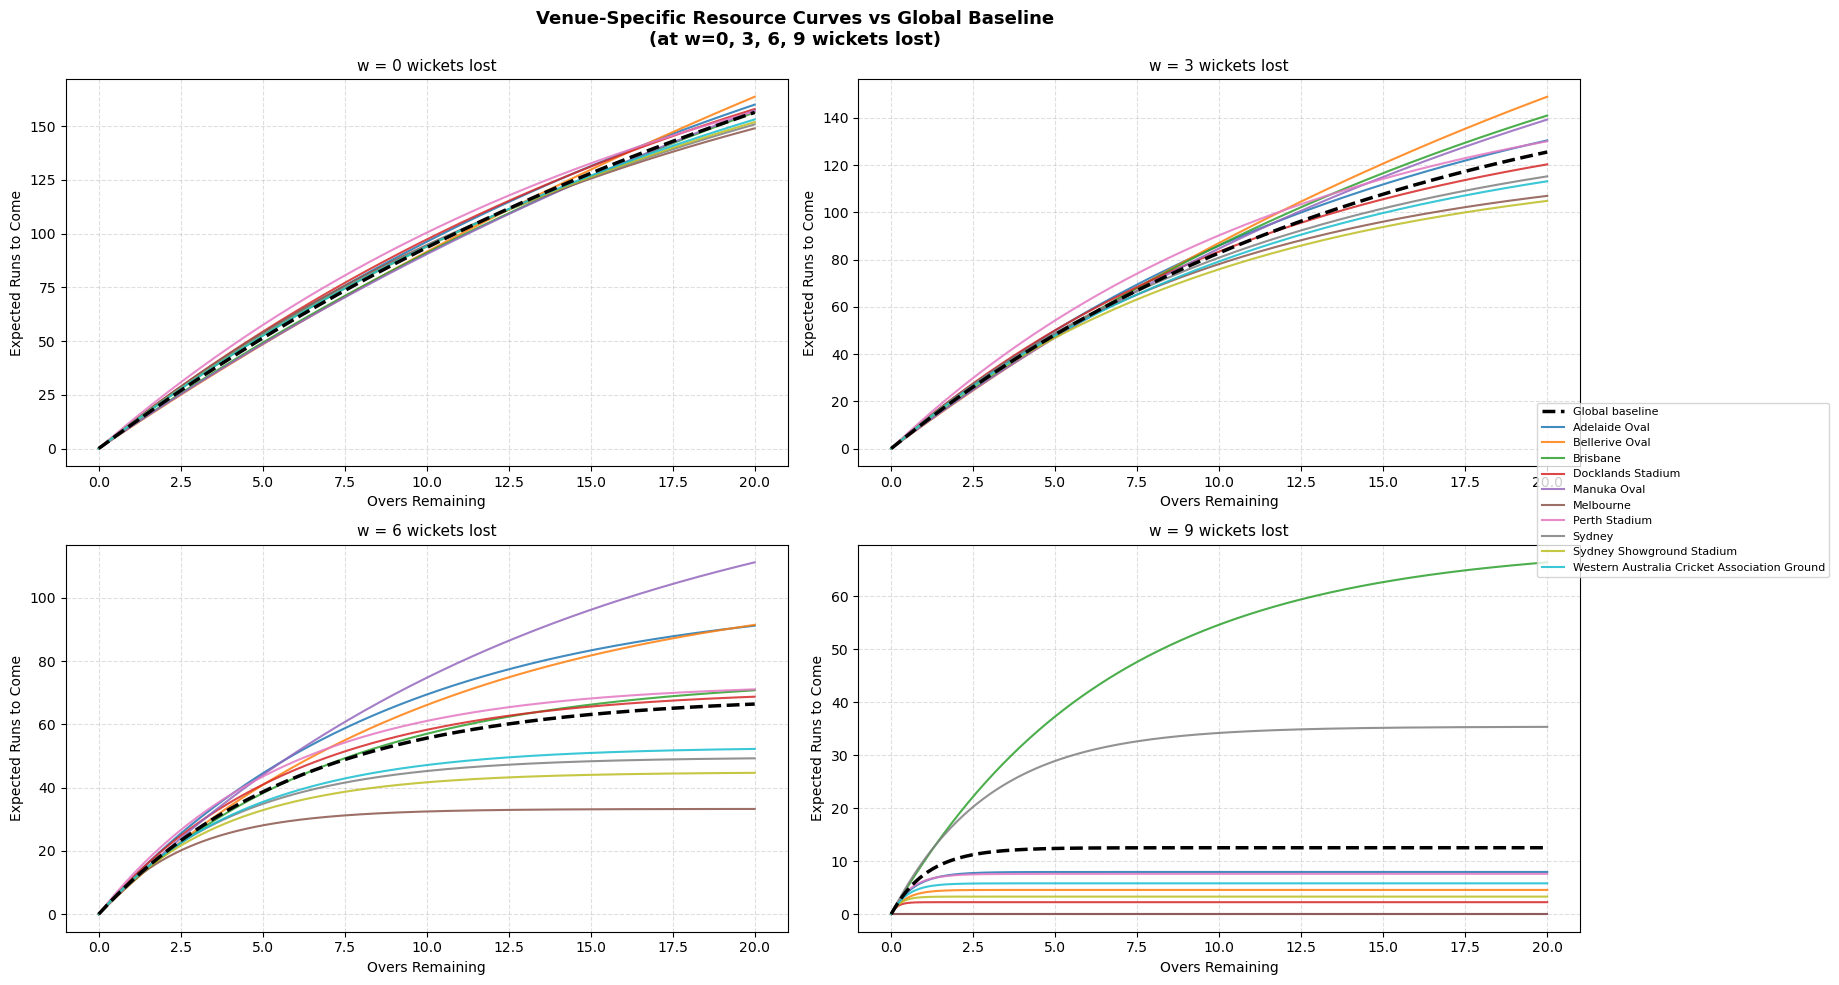

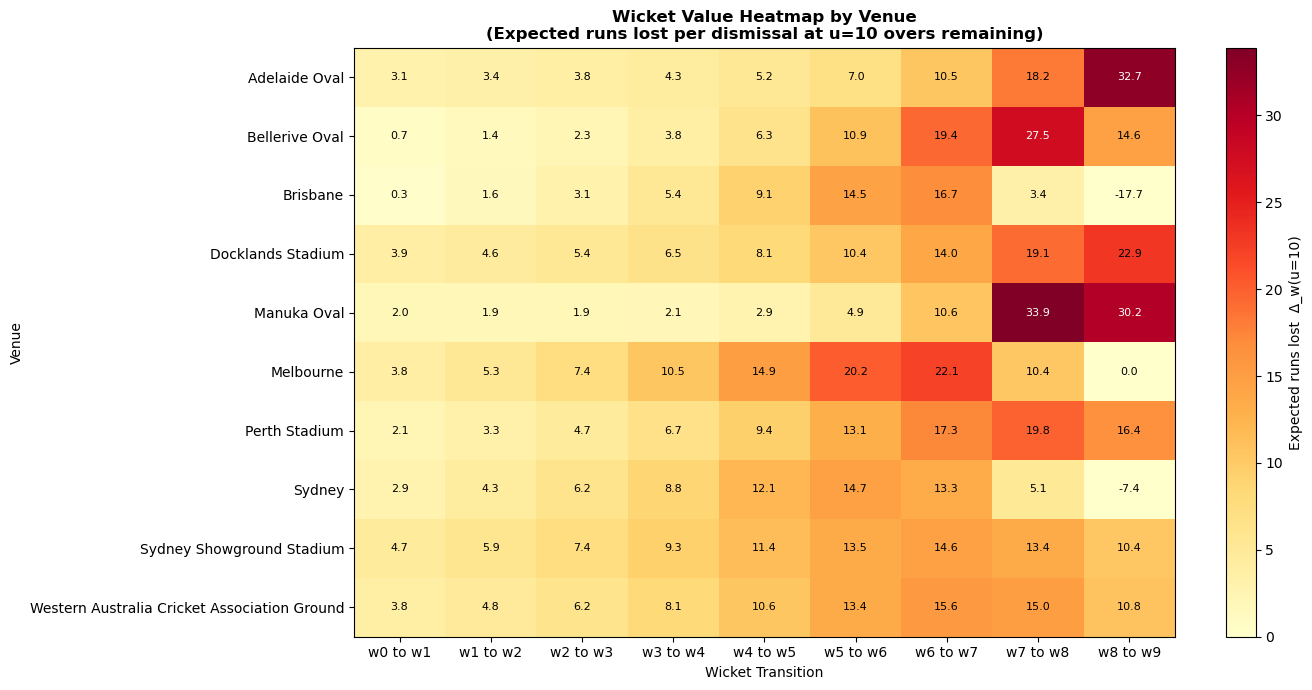


 Module 1 saved to ResearchProjectB/venue_phase_team/venue/
Module 2: Phase specific
  Powerplay                                      G20= 157.3  b=0.0308  MAE=19.48  RMSE=25.14  N=21,744
  Middle                                         G20= 152.2  b=0.0465  MAE=14.10  RMSE=18.18  N=32,446
  Death                                          G20= 151.6  b=0.0468  MAE=6.17  RMSE=8.35  N=17,340


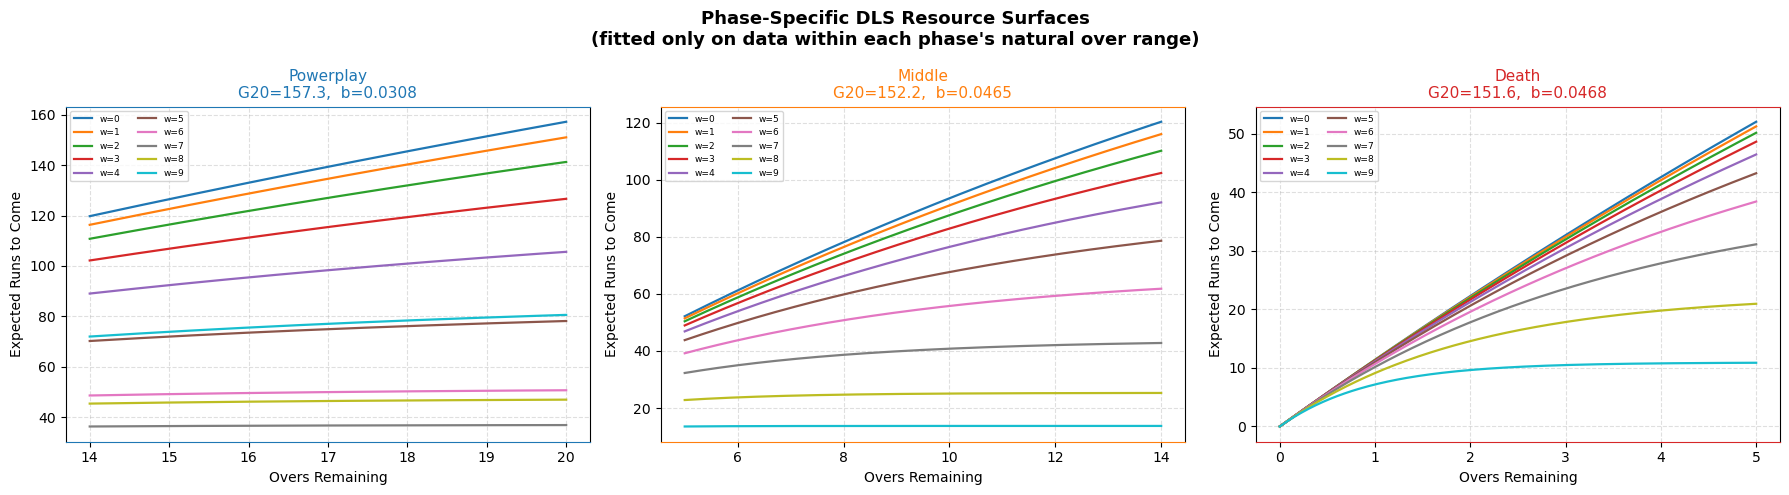

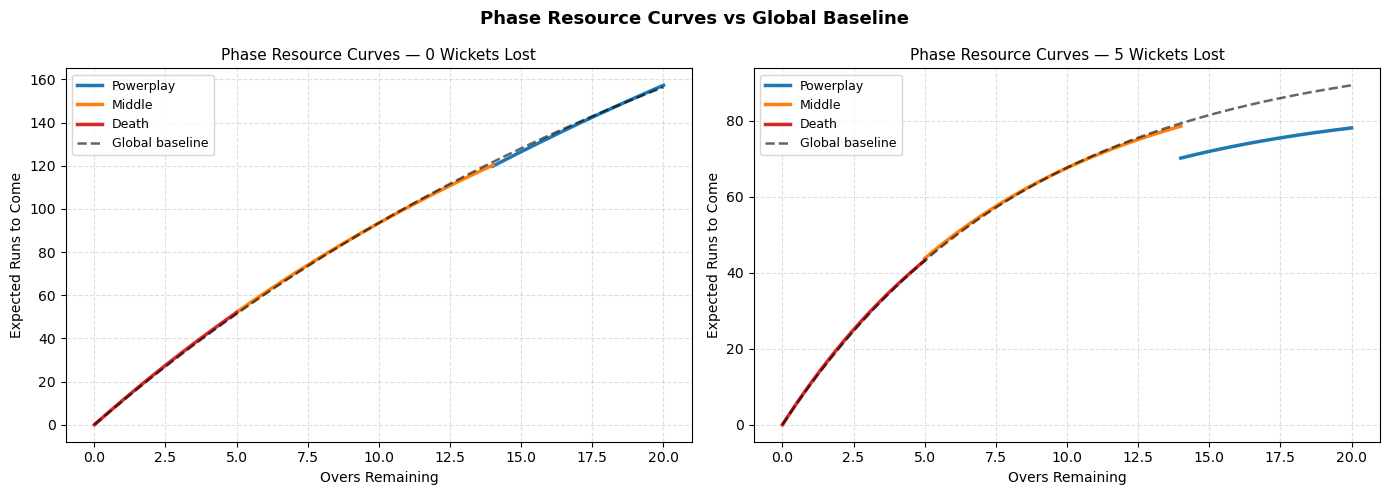

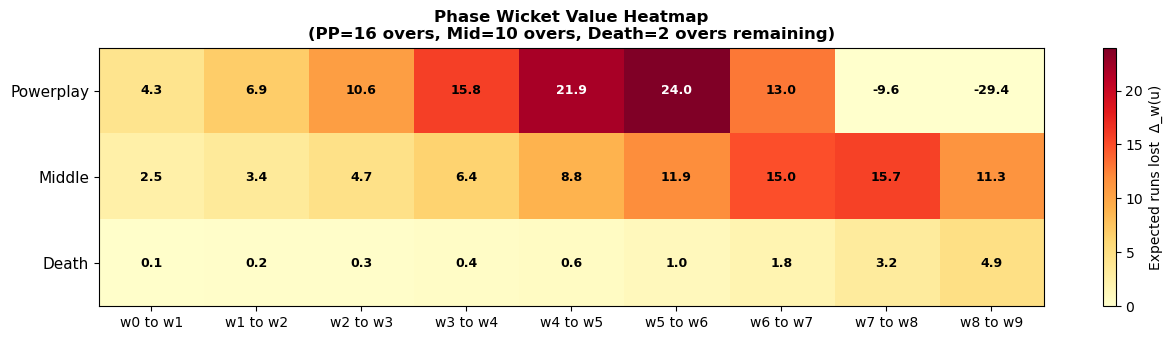

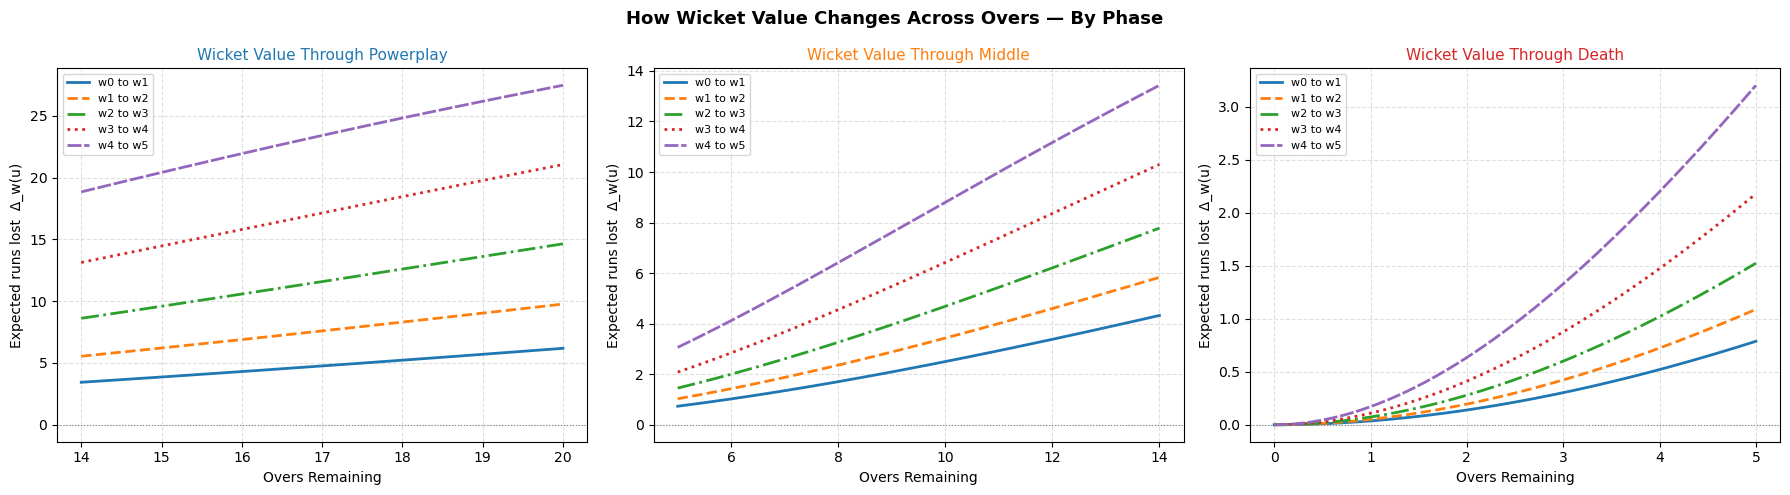


 Module 2 saved to ResearchProjectB/venue_phase_team/phase/
Module 3: Team specific
Teams found: ['Adelaide Strikers', 'Brisbane Heat', 'Hobart Hurricanes', 'Melbourne Renegades', 'Melbourne Stars', 'Perth Scorchers', 'Sydney Sixers', 'Sydney Thunder']
  Adelaide Strikers                              G20= 155.8  b=0.0410  MAE=13.67  RMSE=18.38  N=10,208
  Brisbane Heat                                  G20= 154.1  b=0.0494  MAE=15.23  RMSE=21.08  N=9,481
  Hobart Hurricanes                              G20= 160.4  b=0.0394  MAE=13.46  RMSE=19.13  N=9,220
  Melbourne Renegades                            G20= 155.0  b=0.0262  MAE=11.59  RMSE=15.59  N=7,968
  Melbourne Stars                                G20= 161.0  b=0.0290  MAE=13.09  RMSE=18.22  N=8,263
  Perth Scorchers                                G20= 164.8  b=0.0353  MAE=15.19  RMSE=20.51  N=10,070
  Sydney Sixers                                  G20= 149.9  b=0.0481  MAE=13.60  RMSE=18.99  N=7,714
  Sydney Thunder              

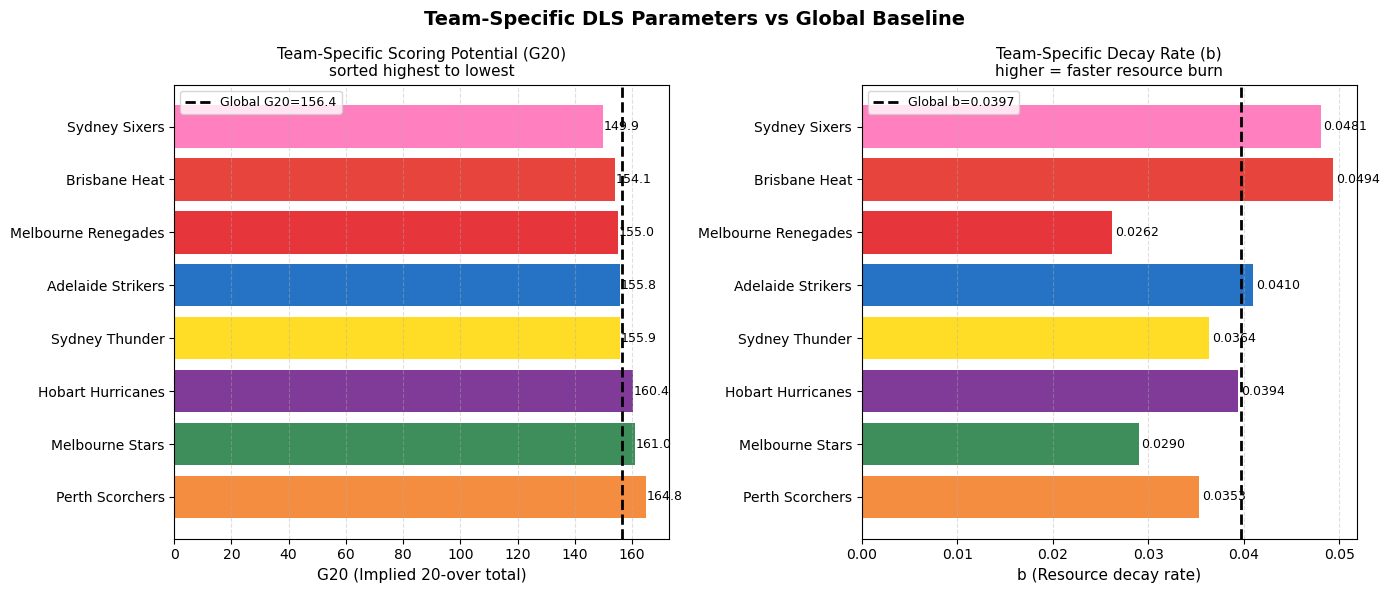

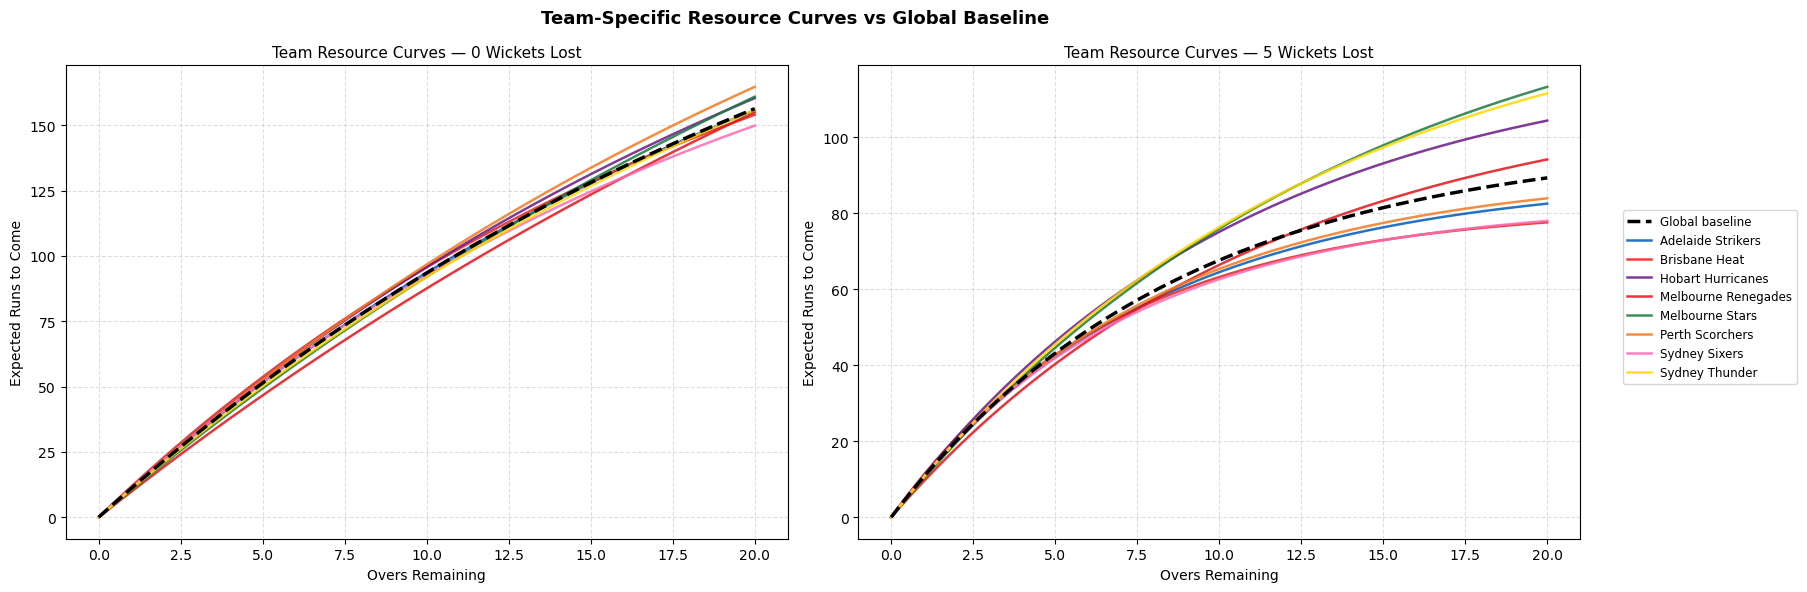

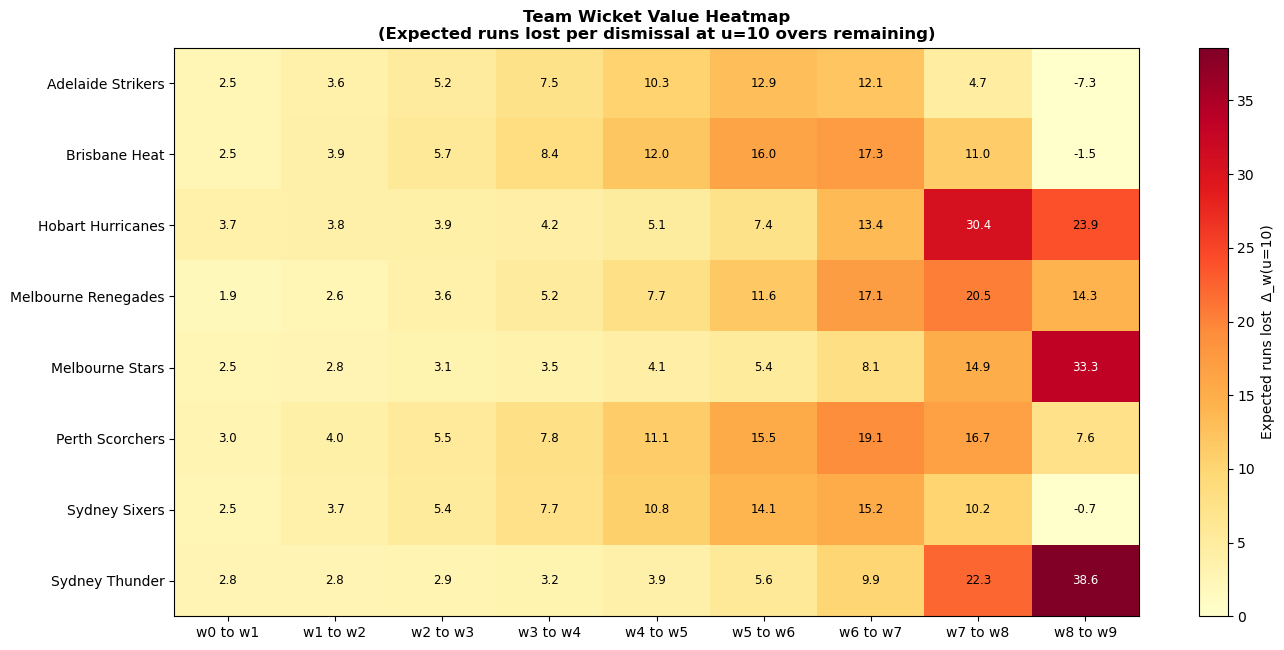


Fitting phase×team interaction models...
  Powerplay×Adelaide Strikers                    G20= 162.5  b=0.0013  MAE=19.42  RMSE=24.73  N=3,096
  Powerplay×Brisbane Heat                        G20= 153.4  b=0.0349  MAE=22.59  RMSE=28.35  N=2,916
  Powerplay×Hobart Hurricanes                    G20= 160.5  b=0.0329  MAE=19.01  RMSE=25.81  N=2,808
  Powerplay×Melbourne Renegades                  G20= 157.4  b=0.0179  MAE=14.59  RMSE=19.39  N=2,412
  Powerplay×Melbourne Stars                      G20= 160.5  b=0.0306  MAE=17.94  RMSE=23.49  N=2,484
  Powerplay×Perth Scorchers                      G20= 158.7  b=0.0380  MAE=21.22  RMSE=26.53  N=3,060
  Powerplay×Sydney Sixers                        G20= 150.9  b=0.0340  MAE=18.85  RMSE=24.73  N=2,376
  Powerplay×Sydney Thunder                       G20= 159.1  b=0.0267  MAE=18.97  RMSE=23.47  N=2,592
  Middle×Adelaide Strikers                       G20= 150.7  b=0.0466  MAE=13.72  RMSE=17.18  N=4,638
  Middle×Brisbane Heat                  

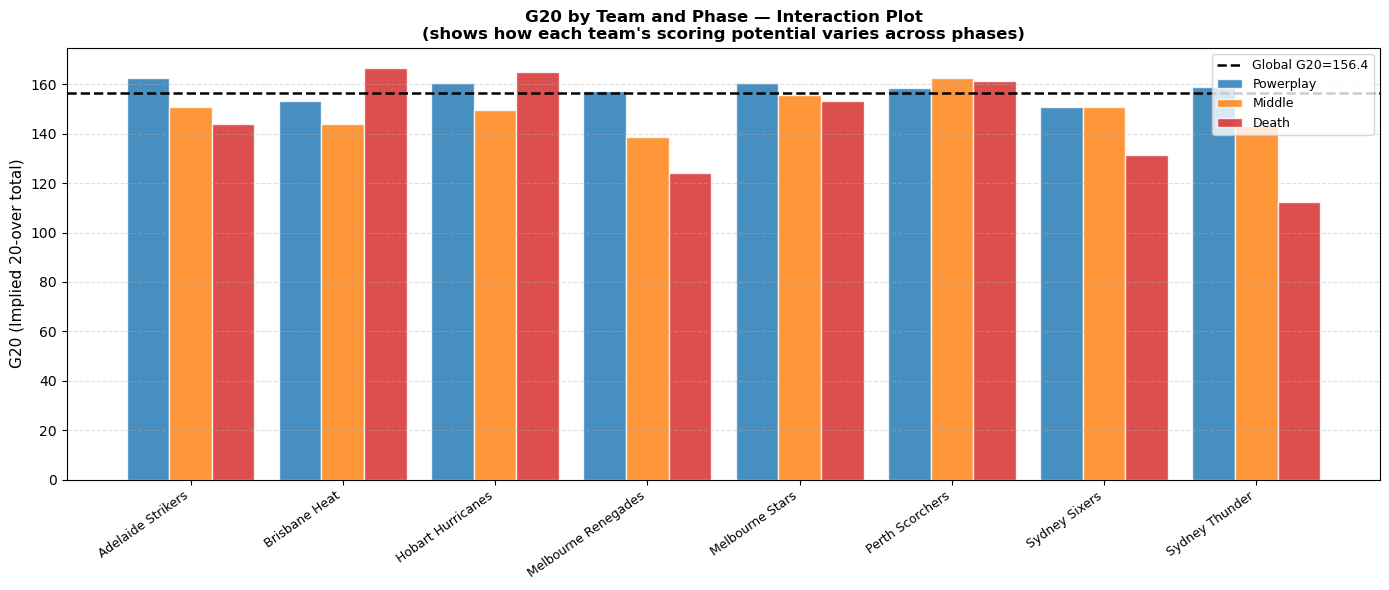

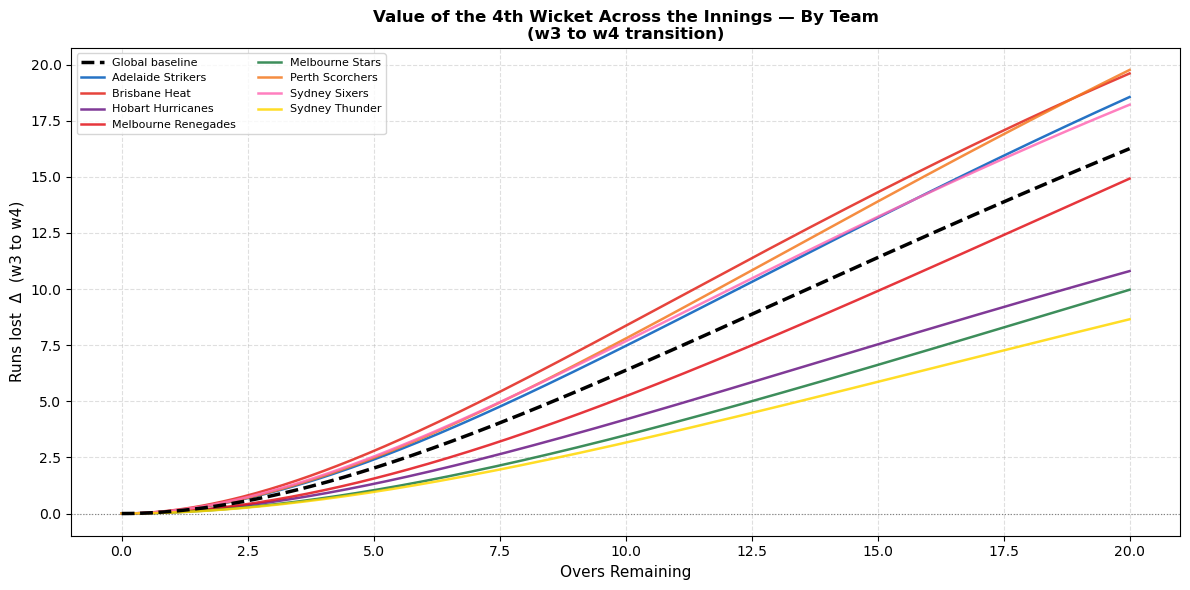

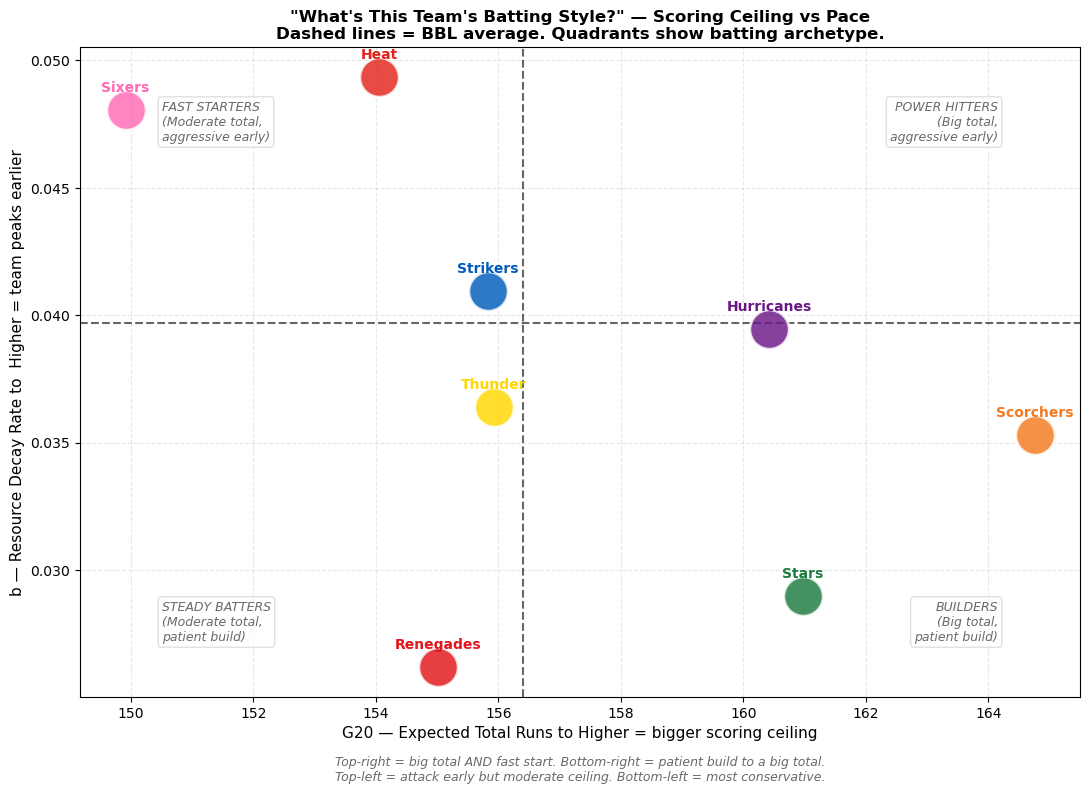


 Module 3 saved to ResearchProjectB/venue_phase_team/team/
Cross comparison
dimension                                            group        G20        b  delta_w3_u10
    Venue                                    Adelaide Oval 160.014452 0.041104      4.296124
    Venue                           Bellerive Oval, Hobart 163.695115 0.023748      3.769443
    Venue Brisbane Cricket Ground, Woolloongabba, Brisbane 156.422750 0.033024      5.420843
    Venue                     Docklands Stadium, Melbourne 157.985212 0.047133      6.548306
    Venue                            Manuka Oval, Canberra 157.303424 0.030132      2.104881
    Venue                         Melbourne Cricket Ground 148.981963 0.055589     10.490816
    Venue                                    Perth Stadium 156.808531 0.057792      6.711040
    Venue                    Sydney Cricket Ground, Sydney 150.827049 0.050956      8.837710
    Venue                        Sydney Showground Stadium 151.906835 0.048149      9.

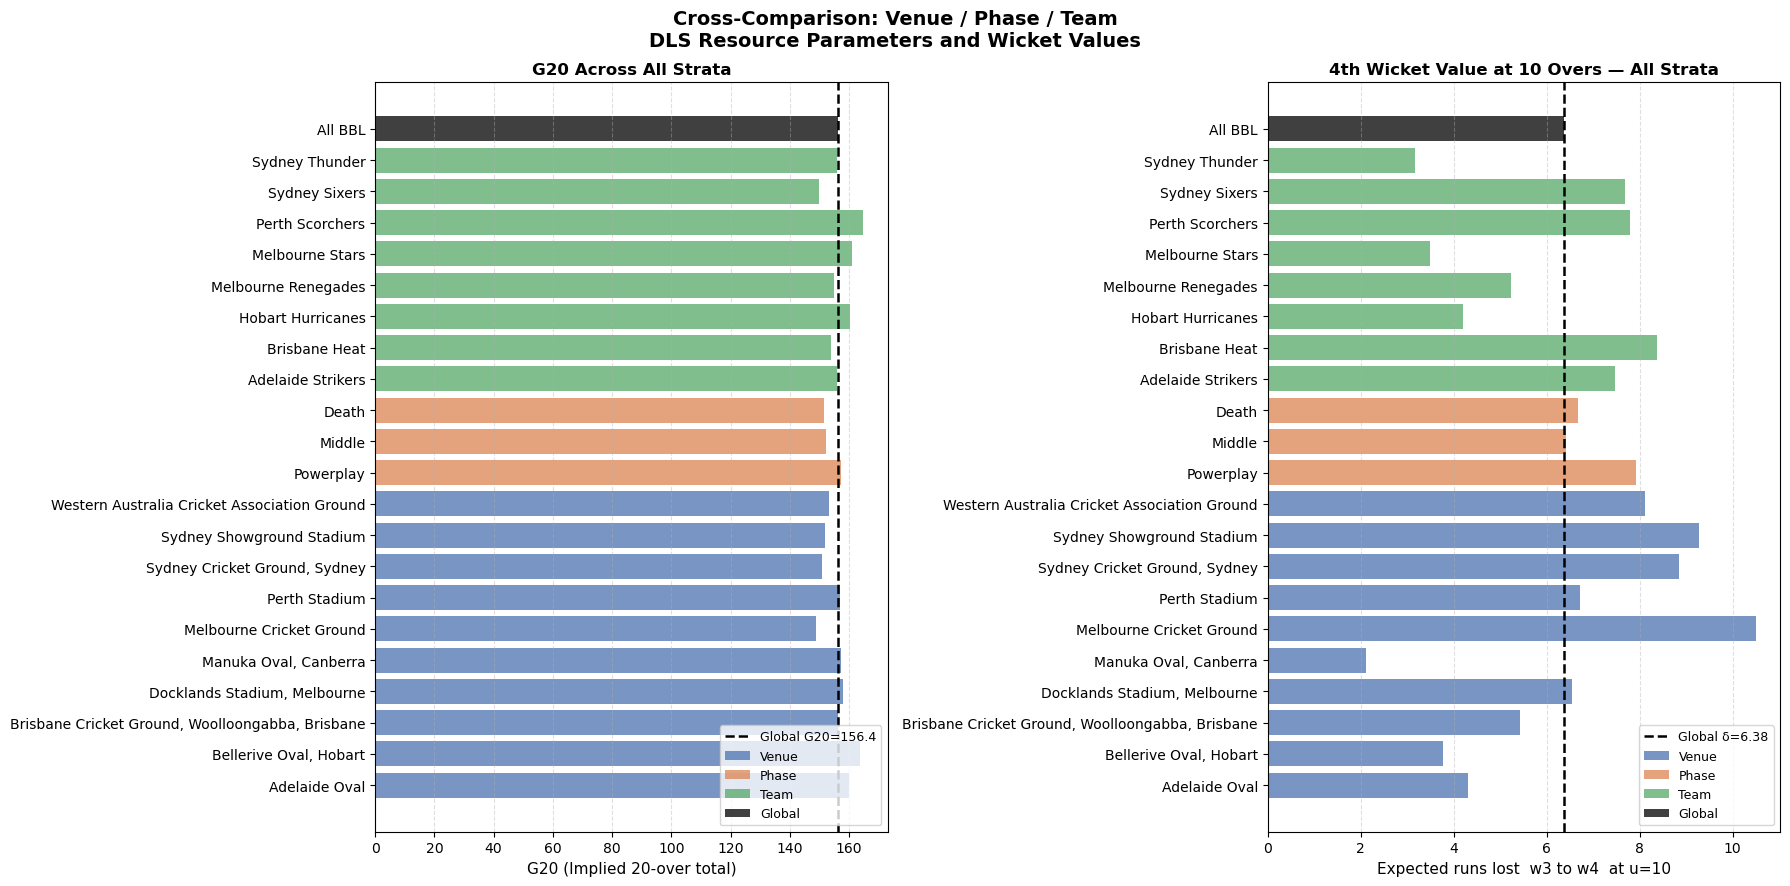

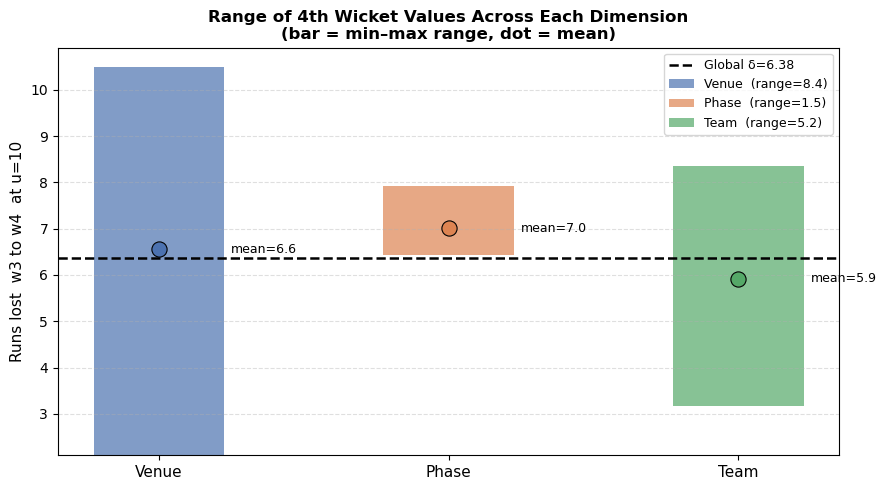


 Cross-comparison saved to ResearchProjectB/venue_phase_team/cross_comparison/


In [115]:
# Main

if __name__ == "__main__":
    # Load
    df = load_data()

    # Global baseline (Project A replication)
    global_params, global_metrics = fit_global(df)

    # Module 1: Venue
    venue_params, venue_df = module_venue(df, global_params, min_matches=20)

    # Module 2: Phase
    phase_params, phase_df = module_phase(df, global_params)

    # Module 3: Team
    team_params, team_df, _ = module_team(df, global_params)

    # Cross-comparison
    cross_df = cross_comparison(global_params, venue_params,
                                phase_params, team_params)